Mushroom Classification Project - Aaron Timalsena

In this project, I use the Mushroom Classification dataset from Kaggle to predict whether a mushroom is edible or not (poisonous) by analyzing it's physical characteristics.
This problem falls under binary classification as mushrooms are sorted according to one of two classes; edible or poisonous

Goal: Predict if a mushroom is edible or poisonous from their given physical characteristics. First looking through the dataset checkiing for any missing or unusual values, then moving forward to plots and tables, then cleaning the categorical columns and finally train the classification models.

In [14]:
#Basic Libraries and Import KaggleHub for downloading the dataset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("uciml/mushroom-classification")

print("Path to dataset files:", dataset_path)

Path to dataset files: C:\Users\Aaron\.cache\kagglehub\datasets\uciml\mushroom-classification\versions\1


In [15]:
# List files in  downloaded dataset folder
folder_files = os.listdir(dataset_path)

# Display available files
folder_files

['mushrooms.csv']

In [17]:
# Create full path to the mushroom CSV file
data_file = os.path.join(dataset_path, "mushrooms.csv")

# Load dataset into a pandas DataFrame
mushrooms = pd.read_csv(data_file)

# Display the first five rows
mushrooms.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [18]:
# Check no. of rows and columns
mushrooms.shape

(8124, 23)

In [19]:
#check column names
mushrooms.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='str')

Initial Dataset Inspecting

Here, I inspect the structure of dataset prior to building ML models, checking the data types, duplicate rows, target class, missing rows and values inside individual feature column.

In [20]:
# print summary of column types and non-null counts
mushrooms.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [21]:
# Count/Check missing or null values in every column
null_counts = mushrooms.isnull().sum()

# Show null counts
null_counts

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [22]:
#Count how often a question mark appears in each column
qmark_counts = (mushrooms == "?").sum()

#Show question mark's counts
qmark_counts

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [24]:
# Count duplicate rows in dataset
num_duplicates = mushrooms.duplicated().sum()

#show duplicate row count
num_duplicates

np.int64(0)

In [25]:
#Count how many mushrooms are in each target class
label_counts = mushrooms["class"].value_counts()

#Show class counts
label_counts

class
e    4208
p    3916
Name: count, dtype: int64

In [26]:
#Compute percentage split across target classes
label_percentages = mushrooms["class"].value_counts(normalize=True) * 100

#show class percentages
label_percentages

class
e    51.797144
p    48.202856
Name: proportion, dtype: float64

In [27]:
# Count how many distinct values each column contains
distinct_counts = mushrooms.nunique()

#Show distinct value counts
distinct_counts

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

In [28]:
# Print the distinct values inside each column
for col in mushrooms.columns:
    print(col)
    print(mushrooms[col].unique())
    print()

class
<StringArray>
['p', 'e']
Length: 2, dtype: str

cap-shape
<StringArray>
['x', 'b', 's', 'f', 'k', 'c']
Length: 6, dtype: str

cap-surface
<StringArray>
['s', 'y', 'f', 'g']
Length: 4, dtype: str

cap-color
<StringArray>
['n', 'y', 'w', 'g', 'e', 'p', 'b', 'u', 'c', 'r']
Length: 10, dtype: str

bruises
<StringArray>
['t', 'f']
Length: 2, dtype: str

odor
<StringArray>
['p', 'a', 'l', 'n', 'f', 'c', 'y', 's', 'm']
Length: 9, dtype: str

gill-attachment
<StringArray>
['f', 'a']
Length: 2, dtype: str

gill-spacing
<StringArray>
['c', 'w']
Length: 2, dtype: str

gill-size
<StringArray>
['n', 'b']
Length: 2, dtype: str

gill-color
<StringArray>
['k', 'n', 'g', 'p', 'w', 'h', 'u', 'e', 'b', 'r', 'y', 'o']
Length: 12, dtype: str

stalk-shape
<StringArray>
['e', 't']
Length: 2, dtype: str

stalk-root
<StringArray>
['e', 'c', 'b', 'r', '?']
Length: 5, dtype: str

stalk-surface-above-ring
<StringArray>
['s', 'f', 'k', 'y']
Length: 4, dtype: str

stalk-surface-below-ring
<StringArray>
['s', 

Inital Inspection Results

Dataset has 8124 rows, 23 columns, target column being `class` where `e` means edible and `p` means poisonous.
All features are stored as letters instead of numbers like using physical traits of mushroom like cap shape, cap color, odor, ring type, habital meaning, they need to be encoded before training ML models.

Missing Values Report
It doesnt contain regular missing values as of `mushrooms.isnull().sum()` but, `stalk-root` contains 2480 question mark values indicating unknown/missing category values.

Since the data is made of descriptions, I’ll keep the `?` marks and count them as a new group rather than deleting them. Removing 2480 entries would throw away too much of the information I need.

In [29]:
#Build a feature summary table
feature_table = pd.DataFrame({
    "Feature": [
        "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
        "gill-attachment", "gill-spacing", "gill-size", "gill-color",
        "stalk-shape", "stalk-root", "stalk-surface-above-ring",
        "stalk-surface-below-ring", "stalk-color-above-ring",
        "stalk-color-below-ring", "veil-color", "ring-number",
        "ring-type", "spore-print-color", "population", "habitat"
    ],
    "Type": ["Categorical"] * 21,
    "Unique Values": [6, 4, 10, 2, 9, 2, 2, 2, 12, 2, 5, 4, 4, 9, 9, 4, 3, 5, 9, 6, 7],
    "Missing (?)": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2480, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "Notes": [
        "b,c,f,k,s,x", "f,g,s,y", "b,c,e,g,n,p,r,u,w,y", "t/f",
        "Strong predictor — many odors are 100% one class",
        "a/f", "c/w", "b/n — narrow gill linked to poisonous",
        "12 categories", "e/t",
        "? replaced with 'unknown' — 2480 rows affected",
        "s,f,k,y", "s,f,y,k", "9 colors", "9 colors",
        "w,n,o,y", "o,t,n", "e,f,l,n,p", "9 colors",
        "a,c,n,s,v,y", "d,g,l,m,p,u,w"
    ]
})

feature_table

,Feature,Type,Unique Values,Missing (?),Notes
0,cap-shape,Categorical,6,0,"b,c,f,k,s,x"
1,cap-surface,Categorical,4,0,"f,g,s,y"
2,cap-color,Categorical,10,0,"b,c,e,g,n,p,r,u,w,y"
3,bruises,Categorical,2,0,t/f
4,odor,Categorical,9,0,Strong predictor — many odors are 100% one class
5,gill-attachment,Categorical,2,0,a/f
6,gill-spacing,Categorical,2,0,c/w
7,gill-size,Categorical,2,0,b/n — narrow gill linked to poisonous
8,gill-color,Categorical,12,0,12 categories
9,stalk-shape,Categorical,2,0,e/t


Only stalk-root has missing data (shown as ?). I’m removing the veil-type column because every mushroom has the exact same value, making it useless for the model.

Data Visualization

I'll use simple charts to look at the different mushroom types and compare their features. These graphs help highlight which traits are most important for identifying the mushrooms.

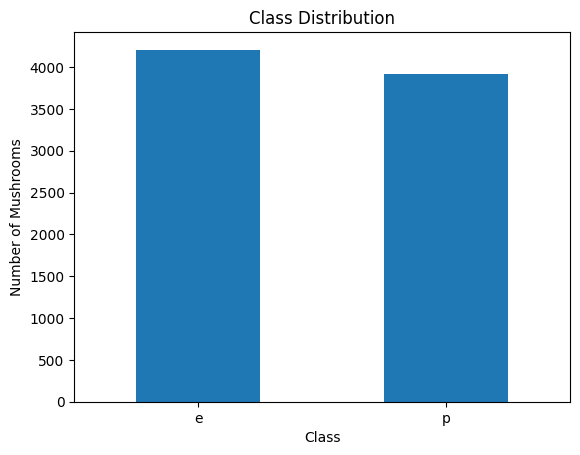

In [41]:
#Plot the target class distribution
label_counts.plot(kind="bar")

# Adding labels and title
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

plt.savefig("class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

The number of edible and poisonous mushrooms is nearly equal, with 4,208 edible and 3,916 poisonous. Since the groups are about the same size, accuracy works well to measure success, though a confusion matrix is still necessary to see the full results.

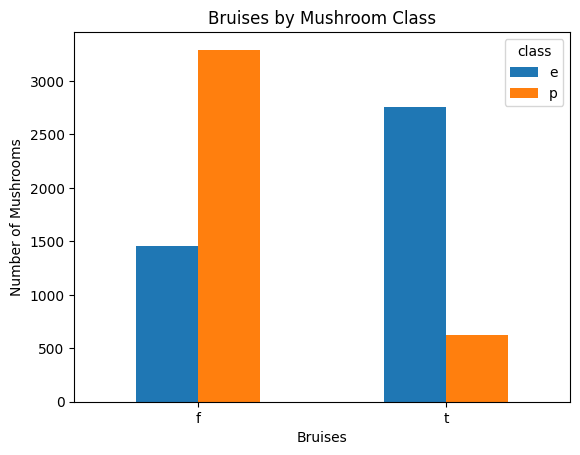

In [42]:
#Comparing bruises values across the two classes
bruises_table = pd.crosstab(mushrooms["bruises"], mushrooms["class"])

#Plotting bruises counts by class
bruises_table.plot(kind="bar")

plt.title("Bruises by Mushroom Class")
plt.xlabel("Bruises")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

plt.savefig("bruises_distribution_by_class.png", bbox_inches="tight", dpi=150)
plt.show()

Bruises shows a noticeable split between edible and poisonous mushrooms. Mushrooms with bruises tend to be more often edible, while those without bruises appear more often in the poisonous class.

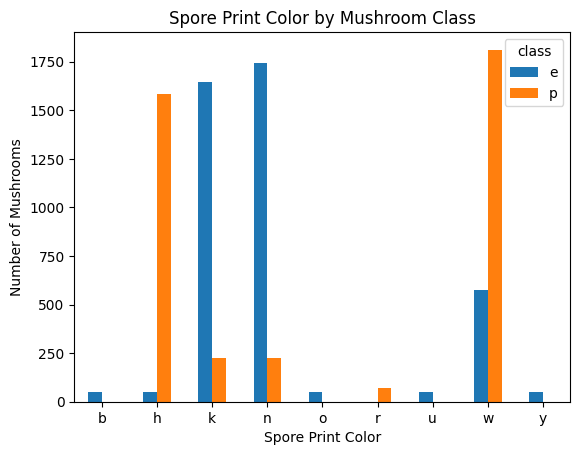

In [43]:
#Compare spore print color across the two classes
spore_table = pd.crosstab(mushrooms["spore-print-color"], mushrooms["class"])

#Plot spore print color counts by class
spore_table.plot(kind="bar")

#Add labels and title
plt.title("Spore Print Color by Mushroom Class")
plt.xlabel("Spore Print Color")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

plt.show()

Spore print color shows clear differences between edible and poisonous mushrooms across several color categories. Some colors appear almost exclusively in one class, suggesting this feature may be a useful predictor.

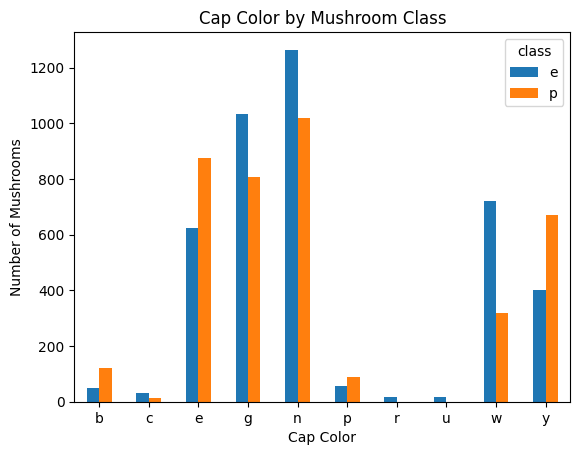

In [44]:
#Compare cap color across the two classes
cap_color_table = pd.crosstab(mushrooms["cap-color"], mushrooms["class"])

#Plot cap color counts by class
cap_color_table.plot(kind="bar")

# Adding labels and title
plt.title("Cap Color by Mushroom Class")
plt.xlabel("Cap Color")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

plt.show()

Cap color has multiple categories with different class patterns. It does not separate the classes as cleanly as some other features, but it still contains information that may help the model.

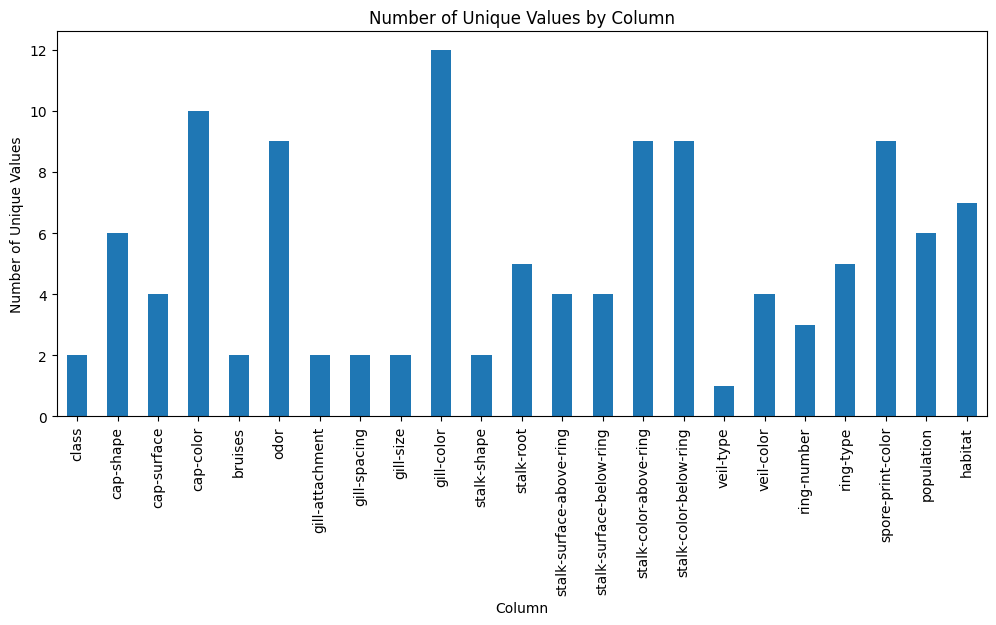

In [45]:
#Plot number of distinct values in each column
distinct_counts.plot(kind="bar", figsize=(12, 5))

#Add labels and title
plt.title("Number of Unique Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Unique Values")
plt.xticks(rotation=90)

plt.show()

While every column is descriptive, they vary in how much detail they provide. I’m dropping the `veil-type` column because it contains the exact same information for every mushroom, making it useless for distinguishing between edible and poisonous types.

In [47]:
#Define a function to show class percentages for given column
def show_class_percentages(column):
    #Count class values per category
    count_tbl = pd.crosstab(mushrooms[column], mushrooms["class"])

    #Compute row-wise percentages
    pct_tbl = pd.crosstab(mushrooms[column], mushrooms["class"], normalize="index") * 100

    #Print count table
    print("Count table for", column)
    display(count_tbl)

    #Print percentage table
    print("Percentage table for", column)
    display(pct_tbl.round(2))

In [48]:
#Check class percentages for selected features
show_class_percentages("bruises")
show_class_percentages("spore-print-color")
show_class_percentages("cap-color")
show_class_percentages("population")

Count table for bruises


class,e,p
bruises,,
f,1456,3292
t,2752,624


Percentage table for bruises


class,e,p
bruises,,
f,30.67,69.33
t,81.52,18.48


Count table for spore-print-color


...

class,e,p
cap-color,,
b,28.57,71.43
c,72.73,27.27
e,41.60,58.40
g,56.09,43.91
n,55.34,44.66
p,38.89,61.11
r,100.00,0.00
u,100.00,0.00
w,69.23,30.77


Count table for population


class,e,p
population,,
a,384,0
c,288,52
n,400,0
s,880,368
v,1192,2848
y,1064,648


Percentage table for population


class,e,p
population,,
a,100.00,0.00
c,84.71,15.29
n,100.00,0.00
s,70.51,29.49
v,29.50,70.50
y,62.15,37.85


The data tables confirm specific patterns that are harder to spot in the charts. Because certain bruise types and scent profiles correlate so strongly with one group, they serve as highly reliable indicators for the model to determine whether a mushroom is edible or poisonous.

Data Cleaning & Prep for Machine Learning

This part focuses on cleaning and organizing the data. I convert all text descriptions into a numeric code and divide the mushrooms into three sets to ensure the Machine learning learns correctly.

In [49]:
#Make working copy of the original DataFrame
data = mushrooms.copy()

#Preview working copy
data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [50]:
#Replace question marks in stalk-root with a named unknown category
data["stalk-root"] = data["stalk-root"].replace("?", "unknown")

#Check updated stalk-root value counts
data["stalk-root"].value_counts()

stalk-root
b          3776
unknown    2480
e          1120
c           556
r           192
Name: count, dtype: int64

The primary problem with the data is in the `stalk-root` column, where missing information is marked with a `?`. Rather than deleting these rows and losing a significant amount of data, I am renaming these values to  `unknown` so they can be included in the analysis.

In [51]:
#Remove veil-type since it only contains one value
data = data.drop(columns=["veil-type"])

#Verify the new column count
data.shape

(8124, 22)

I dropped the `veil-type` column because its data is identical across every single row. Since there is no variation, it provides zero useful information for distinguishing between edible and poisonous mushrooms.

In [53]:
#Split features from the target column
X = data.drop(columns=["class"])
y = data["class"]

#confirm shapes
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (8124, 21)
Target shape: (8124,)


In [54]:
#encode target: edible = 0, poisonous = 1
y = y.map({"e": 0, "p": 1})

#confirm encoded target counts
y.value_counts()

class
0    4208
1    3916
Name: count, dtype: int64

I changed the mushroom categories into numbers: 0 for edible and 1 for poisonous. I chose poisonous as the primary focus (the "positive" class) since identifying dangerous mushrooms is the most critical part of the project.

In [55]:
# Applying one-hot encoding to all categorical feature columns
X_encoded = pd.get_dummies(X, dtype=int)

# Checking the shape after encoding
X_encoded.shape

(8124, 116)

In [56]:
# Previewing the encoded feature matrix
X_encoded.head()

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0


Since the mushroom data consists of descriptions, I used one-hot encoding to translate these categories into a binary format. This process creates a new column for every unique trait, using 1s and 0s to indicate whether a feature is present.

In [57]:
#Import  train/test split utility
from sklearn.model_selection import train_test_split

In [58]:
# First split: 75% for training+validation, 25% held out for testing
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    random_state=7,
    stratify=y
)

# Second split: 80% of the remaining becomes training, 20% becomes validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=7,
    stratify=y_train_full
)

# Printing the final sizes of each split
print("Training features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_val.shape)
print("Testing target:", y_test.shape)

Training features: (4874, 116)
Validation features: (1219, 116)
Testing features: (2031, 116)
Training target: (4874,)
Validation target: (1219,)
Testing target: (2031,)


I divided the mushroom data into three distinct groups: one for teaching the models, one for comparing how well they work, and a final set held back to verify the results on completely unseen information.

In [59]:
#Check that class proportions are preserved across all three splits
print("Training class balance")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation class balance")
print(y_val.value_counts(normalize=True) * 100)

print("\nTesting class balance")
print(y_test.value_counts(normalize=True) * 100)

Training class balance
class
0    51.805499
1    48.194501
Name: proportion, dtype: float64

Validation class balance
class
0    51.763741
1    48.236259
Name: proportion, dtype: float64

Testing class balance
class
0    51.797144
1    48.202856
Name: proportion, dtype: float64


ML (Machine Larning)

In this part of the mushroom classification project, I test three different AI models. I begin with a Decision Tree because its logic is easy to follow, then compare it against two others: K Neighbors and Naive Bayes.

The goal is to sort mushrooms into two groups: edible (0) or poisonous (1).

In [60]:
# Importing the three chosen classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB

# Importing evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

Baseline Model: Decision Tree

The reason I chose Decision Tree as the baseline model is because it is simple to interpret and works well with categorical data that has been one-hot encoded.

In [61]:
#Set up the Decision Tree classifier
tree_model = DecisionTreeClassifier(max_depth=8, random_state=7)

#Fit the model on the training data
tree_model.fit(X_train, y_train)

#Generate predictions on the validation set
tree_val_preds = tree_model.predict(X_val)

#Compute validation accuracy
tree_val_accuracy = accuracy_score(y_val, tree_val_preds)

#Show validation accuracy
tree_val_accuracy

1.0

In [62]:
#Print full classification report for the Decision Tree
print(classification_report(
    y_val,
    tree_val_preds,
    target_names=["edible", "poisonous"]
))

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       631
   poisonous       1.00      1.00      1.00       588

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



K-Nearest Neighbors Model

I use K-Nearest Neighbors because it is a non-parametric method that makes no assumptions about the data distribution and can capture local patterns in categorical feature space.

In [63]:
#Set up KNN classifier with 5 neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

#Fit model on the training data
knn_model.fit(X_train, y_train)

#Generte predictions on validation set
knn_val_preds = knn_model.predict(X_val)

#Compute validation accuracy
knn_val_accuracy = accuracy_score(y_val, knn_val_preds)

#Show validation accuracy
knn_val_accuracy

1.0

In [64]:
#Printing the full classification report for KNN
print(classification_report(
    y_val,
    knn_val_preds,
    target_names=["edible", "poisonous"]
))

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       631
   poisonous       1.00      1.00      1.00       588

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



Naive Bayes Model

I use Bernoulli Naive Bayes because it is designed for binary feature inputs, which is exactly what one-hot encoding produces. It is also fast and works well as a lightweight comparison model.

In [65]:
#Set up the Bernoulli Naive Bayes classifier
nb_model = BernoulliNB()

#Fit model on the training data
nb_model.fit(X_train, y_train)

#Generate predictions on the validation set
nb_val_preds = nb_model.predict(X_val)

#Compute validation accuracy
nb_val_accuracy = accuracy_score(y_val, nb_val_preds)

#Show validation accuracy
nb_val_accuracy

0.9376538146021329

In [66]:
# Printing the full classification report for Naive Bayes
print(classification_report(
    y_val,
    nb_val_preds,
    target_names=["edible", "poisonous"]
))

              precision    recall  f1-score   support

      edible       0.91      0.98      0.94       631
   poisonous       0.98      0.89      0.93       588

    accuracy                           0.94      1219
   macro avg       0.94      0.94      0.94      1219
weighted avg       0.94      0.94      0.94      1219



Model Evaluation and Comparison

In this section, I evaluate the machine learning models using several key metrics: accuracy, precision, recall, and the F1 score. I am paying closest attention to recall, as it is much more dangerous to accidentally label a poisonous mushroom as edible than it is to be over-cautious with an edible one.

In [67]:
#Building a majority-class baseline that always predicts the most common class
majority_label = y_train.mode()[0]

#applying the majority prediction to every validation row
majority_val_preds = np.full(len(y_val), majority_label)

#pairing each model name with its validation predictions
all_model_preds = [
    ["Majority Class Baseline", majority_val_preds],
    ["Decision Tree",           tree_val_preds],
    ["K-Nearest Neighbors",     knn_val_preds],
    ["Naive Bayes",             nb_val_preds]
]

#collecting metric rows
metric_rows = []

#compute metrics for every model
for name, preds in all_model_preds:
    acc  = accuracy_score(y_val,  preds)
    prec = precision_score(y_val, preds, zero_division=0)
    rec  = recall_score(y_val,    preds, zero_division=0)
    f1   = f1_score(y_val,        preds, zero_division=0)

    metric_rows.append([name, acc, prec, rec, f1])

#Build the comparison DataFrame
comparison_df = pd.DataFrame(
    metric_rows,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

#display the comparison table
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Class Baseline,0.517637,0.000000,0.000000,0.000000
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,K-Nearest Neighbors,1.000000,1.000000,1.000000,1.000000
3,Naive Bayes,0.937654,0.977612,0.891156,0.932384


The data tables confirm specific patterns that are harder to spot in the charts. Because certain bruise types, spore print colors, and habitats correlate so strongly with specific groups, they serve as highly reliable indicators for the model to determine whether a mushroom is edible or poisonous.

Verifying Model Results

To ensure the perfect accuracy scores were legitimate, I performed several sanity checks. I confirmed there was no target leakage in the features and verified that the training, validation, and testing sets remained strictly separate with no overlapping data.

In [68]:
#Check whether any encoded column name starts with 'class'
leakage_check = [
    col for col in X_encoded.columns
    if col.startswith("class")
]

#Showing any suspicious columns found
leakage_check

[]

In [70]:
#Verify no row indexes are shared between splits
tv_overlap = len(set(X_train.index).intersection(set(X_val.index)))
tt_overlap = len(set(X_train.index).intersection(set(X_test.index)))
vt_overlap = len(set(X_val.index).intersection(set(X_test.index)))

#Printing overlap counts
print("Train-validation overlap:", tv_overlap)
print("Train-test overlap:",       tt_overlap)
print("Validation-test overlap:",  vt_overlap)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


The verification of model results confirmed there was no target leakage or data overlap. Since the target column was excluded from the features and the data splits remained unique, the perfect accuracy is likely due to the strong, distinct patterns within the mushroom traits.

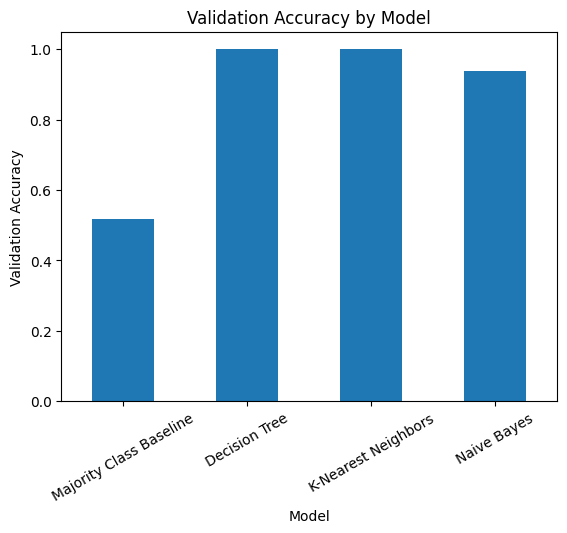

In [72]:
#plotting validation accuracy for all models
comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

#add labels and title
plt.title("Validation Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.xticks(rotation=30)

plt.savefig("validation_of_the_accuracy.png", bbox_inches="tight", dpi=150)
plt.show()

Final Testing Performance

Once the validation stage was complete, I applied the K-Nearest Neighbors model to the final testing set. This testing sample remained completely untouched during the training and comparison phases to ensure an unbiased evaluation of the model's real-world accuracy.

In [73]:
#Generate predictions on the held-out test set
knn_test_preds = knn_model.predict(X_test)

#Compute final test accuracy
knn_test_accuracy = accuracy_score(y_test, knn_test_preds)

#showing the final test accuracy
knn_test_accuracy

1.0

In [74]:
#Print classification report on test set
print(classification_report(
    y_test,
    knn_test_preds,
    target_names=["edible", "poisonous"]
))

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00      1052
   poisonous       1.00      1.00      1.00       979

    accuracy                           1.00      2031
   macro avg       1.00      1.00      1.00      2031
weighted avg       1.00      1.00      1.00      2031



In [75]:
# Computing the confusion matrix on the test set
knn_test_cm = confusion_matrix(y_test, knn_test_preds)

# Displaying the raw confusion matrix
knn_test_cm

array([[1052,    0],
       [   0,  979]])

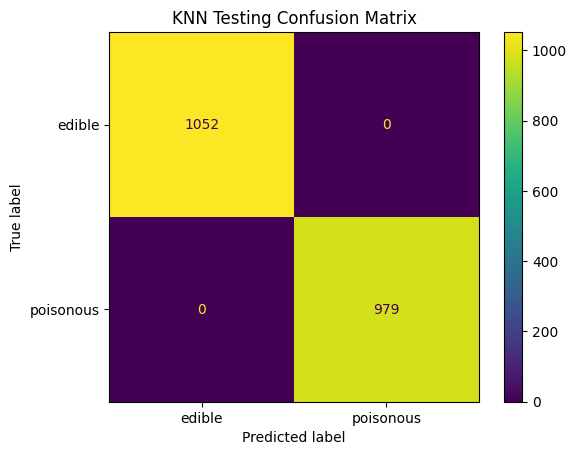

In [76]:
#Plott confusion matrix for the KNN test predictions
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_test_preds,
    display_labels=["edible", "poisonous"]
)

#Adding a title
plt.title("KNN Testing Confusion Matrix")

plt.savefig("confusion_matrix_test.png", bbox_inches="tight", dpi=150)
plt.show()

Final Testing Results

The K-Nearest Neighbors model performed exceptionally well on the independent testing set. Because I verified that the target labels were not leaked into the features and the data rows were strictly separated, these results confirm that the physical mushroom traits are highly reliable indicators of edibility.

Identifying Key Predictors

To understand what drives the model's decisions, I analyzed the feature importance values from the Decision Tree. Since the data was one-hot encoded, these scores highlight which specific category traits (like a certain odor or gill size) were most influential in classifying each mushroom.

In [77]:
#Build DataFrame of Decision Tree feature importances
importance_df = pd.DataFrame({
    "Feature":    X_encoded.columns,
    "Importance": tree_model.feature_importances_
})

#Sort by importance from highest to lowest
importance_df = importance_df.sort_values(by="Importance", ascending=False)

#Show top 20 features
importance_df.head(20)

,Feature,Importance
27,odor_n,0.608730
20,bruises_f,0.174722
28,odor_p,0.093138
24,odor_f,0.066271
99,spore-print-color_r,0.035243
63,stalk-surface-below-ring_y,0.012888
68,stalk-color-above-ring_n,0.005727
21,bruises_t,0.002403
1,cap-shape_c,0.000819
36,gill-size_n,0.000058


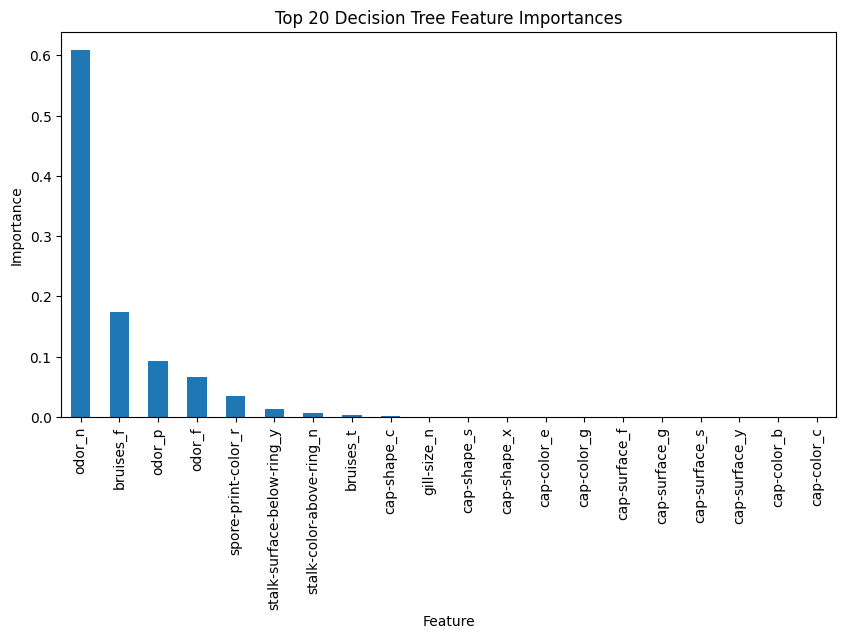

In [78]:
#Plotting top 20 most important features
importance_df.head(20).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

#adding labels and title
plt.title("Top 20 Decision Tree Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=90)

plt.show()

The most influential features identified by the model align with the physical traits that showed distinct patterns during the initial data exploration. This confirms that the visual trends noted earlier, specifically where certain traits clearly separated edible from poisonous varieties, are indeed the primary drivers of the model's predictions.

Conclusion

This project established a comprehensive machine learning pipeline to classify mushrooms. The workflow included data inspection, cleaning, exploratory visualization, and encoding, followed by splitting the data into training, validation, and testing sets to evaluate various models.

Key data preprocessing steps involved:

Handling Missing Values: Rather than losing data by deleting rows, I reclassified the ? marks in the stalk-root column as an unknown category.

Feature Selection: I removed veil-type because it contained only one value across the entire dataset, making it useless for classification.

While the majority-class baseline was ineffective, the Decision Tree, K-Nearest Neighbors, and Naive Bayes models all demonstrated high validation accuracy. The KNN model specifically maintained this strong performance on the final test set. Rigorous validition of accuracy tests checks confirmed that these results were valid and not caused by data overlap or target leakage.

However, these high performance scores should be viewed in context; the dataset is exceptionally clean and the classes are easily separable. In a real-world scenario with more "noisy" or ambiguous data, these models might require further tuning to maintain such accuracy.